# ЛЗ 6. Вероятностный прогноз сроков ENUWay

Notebook использует исторический weekly throughput закрытых issues публичного репозитория
[Pallets Click](https://github.com/pallets/click) за 26 завершённых недель. Выборка служит
внешним proxy, потому что ENUWay пока не имеет собственной истории завершения задач.

**Модель:** 10 000 прогонов, backlog 18 элементов, bootstrap выборка недельного throughput
с возвращением, фиксированный seed `20261008`. Прогноз начинается 12.10.2026.

In [1]:
from pathlib import Path
from datetime import date, timedelta
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20261008
RUNS = 10_000
BACKLOG_ITEMS = 18
FORECAST_START = date(2026, 10, 12)
BASE = Path.cwd()
if not (BASE / "historical-throughput.csv").exists():
    BASE = BASE / "docs" / "forecast"
assert (BASE / "historical-throughput.csv").exists(), "Запустите notebook из docs/forecast или корня репозитория"
plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#1F4E78"
ORANGE = "#E07A3F"
BASE

WindowsPath('C:/Users/L/Documents/ChatGPT/Управление IT-проектами/ENUWay-repo/docs/forecast')

## 1. Исторический throughput

In [2]:
history = pd.read_csv(BASE / "historical-throughput.csv", parse_dates=["week_start", "week_end"])
source = json.loads((BASE / "data-source.json").read_text(encoding="utf-8"))
throughput = history["throughput_items"].to_numpy(dtype=int)
assert len(history) == 26
assert throughput.sum() == source["closed_issues"]
summary = pd.Series({
    "Недель в выборке": len(throughput),
    "Закрыто issues": int(throughput.sum()),
    "Среднее в неделю": throughput.mean(),
    "Медиана в неделю": np.median(throughput),
    "Минимум": throughput.min(),
    "Максимум": throughput.max(),
})
display(summary.to_frame("Значение").round(2))
display(history)

,Значение
Недель в выборке,26.00
Закрыто issues,106.00
Среднее в неделю,4.08
Медиана в неделю,3.00
Минимум,0.00
Максимум,16.00


,week_start,week_end,throughput_items
0,2026-04-06,2026-04-12,3
1,2026-04-13,2026-04-19,9
2,2026-04-20,2026-04-26,1
3,2026-04-27,2026-05-03,8
4,2026-05-04,2026-05-10,3
5,2026-05-11,2026-05-17,8
6,2026-05-18,2026-05-24,16
7,2026-05-25,2026-05-31,9
8,2026-06-01,2026-06-07,2
9,2026-06-08,2026-06-14,4


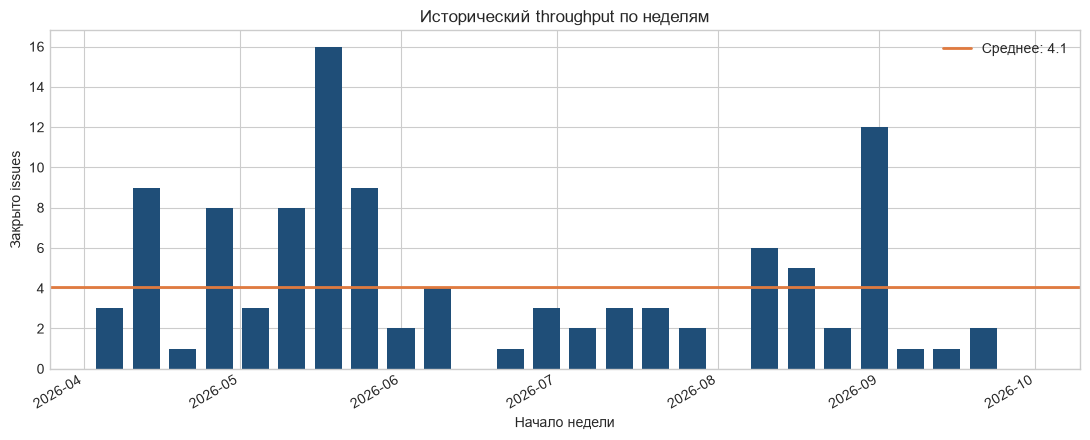

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(history["week_start"], throughput, width=5.2, color=BLUE)
ax.axhline(throughput.mean(), color=ORANGE, linewidth=2, label=f"Среднее: {throughput.mean():.1f}")
ax.set(title="Исторический throughput по неделям", xlabel="Начало недели", ylabel="Закрыто issues")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(BASE / "historical-throughput.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Монте-Карло: 10 000 прогонов

In [4]:
rng = np.random.default_rng(SEED)
weeks_to_finish = np.empty(RUNS, dtype=int)
for run in range(RUNS):
    completed = 0
    weeks = 0
    while completed < BACKLOG_ITEMS:
        completed += int(rng.choice(throughput))
        weeks += 1
        if weeks > 520:
            raise RuntimeError("Симуляция не сходится")
    weeks_to_finish[run] = weeks

percentile_levels = [50, 70, 85, 95]
percentile_weeks = {
    p: int(np.quantile(weeks_to_finish, p / 100, method="higher"))
    for p in percentile_levels
}
percentile_dates = {
    p: FORECAST_START + timedelta(days=7 * weeks - 1)
    for p, weeks in percentile_weeks.items()
}
forecast = pd.DataFrame({
    "Вероятность завершить не позже": [f"P{p}" for p in percentile_levels],
    "Недель": [percentile_weeks[p] for p in percentile_levels],
    "Дата": [percentile_dates[p].strftime("%d.%m.%Y") for p in percentile_levels],
})
display(forecast)
forecast.to_csv(BASE / "forecast-summary.csv", index=False, encoding="utf-8-sig")

,Вероятность завершить не позже,Недель,Дата
0,P50,5,15.11.2026
1,P70,6,22.11.2026
2,P85,7,29.11.2026
3,P95,9,13.12.2026


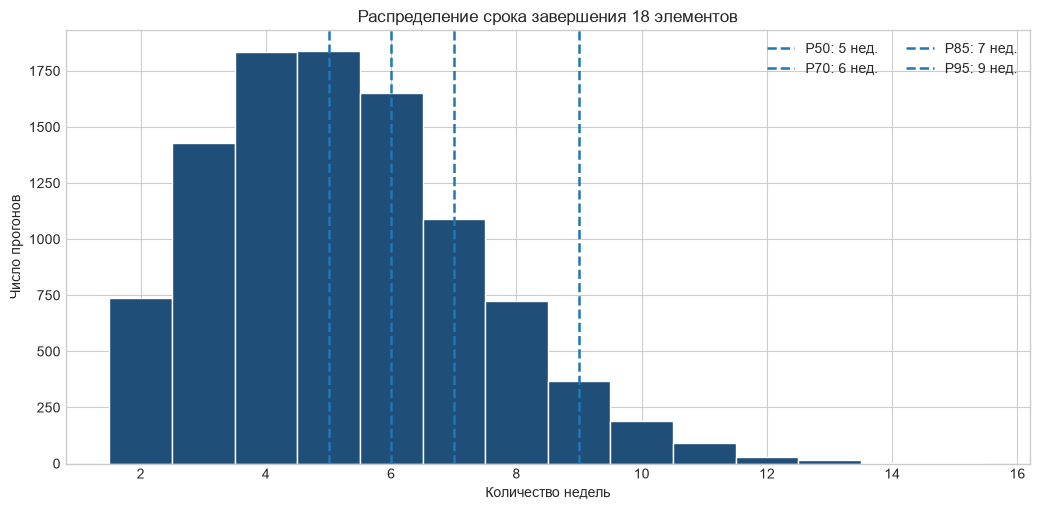

In [5]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
bins = np.arange(weeks_to_finish.min() - 0.5, weeks_to_finish.max() + 1.5, 1)
ax.hist(weeks_to_finish, bins=bins, color=BLUE, edgecolor="white")
for p in percentile_levels:
    ax.axvline(percentile_weeks[p], linestyle="--", linewidth=1.8, label=f"P{p}: {percentile_weeks[p]} нед.")
ax.set(title="Распределение срока завершения 18 элементов", xlabel="Количество недель", ylabel="Число прогонов")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(BASE / "completion-histogram.png", dpi=180, bbox_inches="tight")
plt.show()

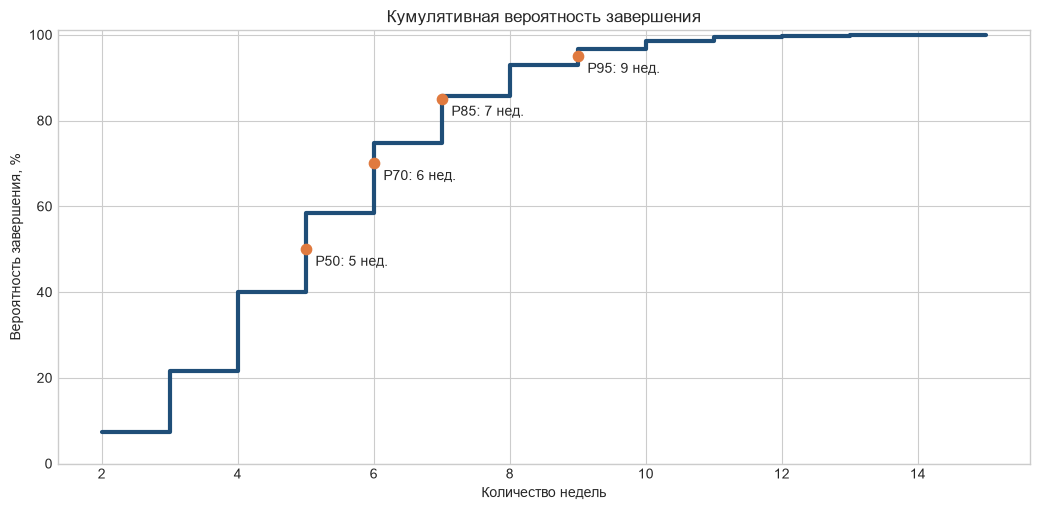

In [6]:
values, counts = np.unique(weeks_to_finish, return_counts=True)
cdf = np.cumsum(counts) / RUNS
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.step(values, cdf * 100, where="post", color=BLUE, linewidth=3)
for p in percentile_levels:
    ax.scatter(percentile_weeks[p], p, s=55, color=ORANGE, zorder=3)
    ax.annotate(f"P{p}: {percentile_weeks[p]} нед.", (percentile_weeks[p], p), xytext=(7, -12), textcoords="offset points")
ax.set(title="Кумулятивная вероятность завершения", xlabel="Количество недель", ylabel="Вероятность завершения, %", ylim=(0, 101))
fig.tight_layout()
fig.savefig(BASE / "completion-cdf.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Сравнение с детерминированной оценкой по story points

In [7]:
backlog = pd.read_csv(BASE.parent / "requirements" / "backlog.csv")
original_sp = int(backlog["Story Points"].sum())
poker = pd.read_csv(BASE / "planning-poker.csv")
original_first_ten = int(backlog.iloc[:10]["Story Points"].sum())
revised_first_ten = int(poker["Consensus SP"].sum())
revised_total_sp = original_sp - original_first_ten + revised_first_ten
assumed_velocity = 14
deterministic_weeks = math.ceil(revised_total_sp / assumed_velocity)
deterministic_date = FORECAST_START + timedelta(days=7 * deterministic_weeks - 1)
comparison = pd.DataFrame([
    ["Story points", revised_total_sp, deterministic_weeks, deterministic_date.strftime("%d.%m.%Y"), "Одна дата"],
    ["Монте-Карло P50", BACKLOG_ITEMS, percentile_weeks[50], percentile_dates[50].strftime("%d.%m.%Y"), "50%"],
    ["Монте-Карло P85", BACKLOG_ITEMS, percentile_weeks[85], percentile_dates[85].strftime("%d.%m.%Y"), "85%"],
    ["Монте-Карло P95", BACKLOG_ITEMS, percentile_weeks[95], percentile_dates[95].strftime("%d.%m.%Y"), "95%"],
], columns=["Метод", "Объём", "Недель", "Дата", "Уверенность"])
display(comparison)
print(f"После покера оценка выросла с {original_sp} до {revised_total_sp} SP.")
print("Детерминированный расчёт использует одну скорость и скрывает разброс недельного throughput.")

,Метод,Объём,Недель,Дата,Уверенность
0,Story points,75,6,22.11.2026,Одна дата
1,Монте-Карло P50,18,5,15.11.2026,50%
2,Монте-Карло P85,18,7,29.11.2026,85%
3,Монте-Карло P95,18,9,13.12.2026,95%


После покера оценка выросла с 69 до 75 SP.
Детерминированный расчёт использует одну скорость и скрывает разброс недельного throughput.


**Почему оценки расходятся**

- Story points оценивают относительную сложность, а throughput считает завершённые элементы независимо от размера.
- Детерминированный расчёт предполагает постоянные 14 SP в неделю. Monte Carlo повторяет наблюдавшийся разброс, включая слабые недели.
- Внешняя история Click не отражает состав команды ENUWay. После нескольких собственных недель прогноз нужно пересчитать на данных ENUWay.

## 4. Planning poker для 10 историй ENUWay

In [8]:
display(poker)
votes = poker[["Participant 1", "Participant 2", "Participant 3"]]
spread = votes.max(axis=1) - votes.min(axis=1)
poker_summary = pd.DataFrame({
    "Историй": [len(poker)],
    "Историй с разбросом": [(spread > 0).sum()],
    "Максимальный разброс": [spread.max()],
    "Сумма консенсуса SP": [poker["Consensus SP"].sum()],
})
display(poker_summary)

,ID,Story,Participant 1,Participant 2,Participant 3,Consensus SP,Reason
0,US-01,ENU аккаунтымен тіркелу,3,5,8,5,ENU доменін тексеру және теріс сценарий әртүрл...
1,US-02,Профильді толтыру,2,3,3,3,Міндетті өрістер мен құпиялық тексеруі нақтыланды
2,US-03,Бағыт пен күн бойынша іздеу,3,5,8,5,"Сүзгілер, сұрыптау және бос нәтиже күйі толық ..."
3,US-04,Сапар карточкасын көру,3,3,5,3,Деректер құрамы мен жабық сапар күйі талқыланды
4,US-05,Жаңа сапар құру,5,8,8,8,"Draft күйі, валидация және жариялау ережесі жа..."
5,US-06,Орын санын белгілеу,1,2,3,2,Шекаралық мәндер мен орын санының өзгеруі нақт...
6,US-07,Шығын үлесін көрсету,1,2,3,2,Сома диапазоны мен көрсету форматы әртүрлі бағ...
7,US-08,Қосылу сұрауын жіберу,3,5,8,5,Бос орынды бір уақытта өзгерту және хабарлама ...
8,US-09,Сұрауды қабылдау немесе қабылдамау,5,8,13,8,"Қайталанған шешім, орын саны және race conditi..."
9,US-10,Менің сапарларым,2,3,5,3,Алдағы және өткен сапарларды топтау ережесі на...


,Историй,Историй с разбросом,Максимальный разброс,Сумма консенсуса SP
0,10,10,8,44


**Что обнаружили на обсуждении**

Самый большой разброс появился в US-09. Один участник оценивал только экран решения, другой учёл
атомарное изменение мест, повторный запрос и конфликт одновременных действий. Для US-05 команда
добавила Draft, валидацию и правила публикации. Расхождения возникали из-за скрытых зависимостей
и разного понимания состояния Done.

## 5. Формулировка для заказчика

In [9]:
print(f"При текущем объёме 18 элементов вероятность завершить до {percentile_dates[85]:%d.%m.%Y} составляет 85%.")
print(f"Медианный срок P50 — {percentile_dates[50]:%d.%m.%Y}, консервативный P95 — {percentile_dates[95]:%d.%m.%Y}.")
print("Прогноз изменится при изменении объёма, размера команды, блокировках или устойчивом изменении throughput.")

При текущем объёме 18 элементов вероятность завершить до 29.11.2026 составляет 85%.
Медианный срок P50 — 15.11.2026, консервативный P95 — 13.12.2026.
Прогноз изменится при изменении объёма, размера команды, блокировках или устойчивом изменении throughput.
